# Análisis Estadístico Exhaustivo y Reporte de Resultados: Teclado Matemático Virtual vs. Pizarra Digital Manuscrita en Mateo Tutor

**Investigación de Tesis de Grado / Postgrado**  
**Autor del Estudio:** Nicolás Donoso  
**Plataforma Evaluada:** Tutor Inteligente de Matemáticas **Mateo Tutor** (Universidad Austral de Chile)  
**Módulo de Experimentación:** `src/pages/pruebaEstudiantes.tsx`  
**Datasets Analizados:**
1. `data_estudio_nicolasdonoso.xlsx` ($N = 14$ estudiantes, $84$ ensayos experimentales de telemetría y NASA-TLX).
2. `Encuesta_ Uso de Tablets en Matemáticas (Respuestas).xlsx` ($N = 14$ estudiantes, Perfil Inicial y Experiencia Previa).
3. `Encuesta Final_ Evaluación del Sistema de Ecuaciones (Respuestas).xlsx` ($N = 14$ estudiantes, Evaluación Cualitativa y Preferencia Final).

---

### Índice General del Documento

1. **[1. Introducción, Justificación Teórica e Hipótesis de Investigación](#1-introducción-justificación-teórica-e-hipótesis-de-investigación)**
   - 1.1 Contexto y Problema de Interacción Humano-Computador (HCI)
   - 1.2 Hipótesis Experimentales Formales ($H_1, H_2, H_3$)
   - 1.3 Definición de Variables y Niveles de Complejidad
2. **[2. Metodología Experimental, Control de Sesgos y Caracterización de la Muestra](#2-metodología-experimental-control-de-sesgos-y-caracterización-de-la-muestra)**
   - 2.1 Inicialización del Entorno Científico y Estilos Visuales
   - 2.2 Ingesta de Datos y Control de Balanceo Experimental (Tablas 2.1 y 2.2)
   - 2.3 Perfil Académico y Experiencia Previa con Tablets (Tablas 2.3 y 2.4 - Pre-Encuesta)
   - 2.4 Cruce entre Experiencia Previa y Rendimiento Real (Tabla 2.5)
   - 2.5 Análisis Metodológico de la Muestra y Control de Sesgos
3. **[3. Estadísticas Descriptivas Comparativas](#3-estadísticas-descriptivas-comparativas)**
   - 3.1 Descriptivas Globales Lado a Lado (Tabla 3.1)
   - 3.2 Descriptivas por Nivel de Complejidad (Tabla 3.2)
4. **[4. Inferencia Estadística, Contrastes Pareados, ANOVA de Medidas Repetidas y Matrices Paso a Paso](#4-inferencia-estadística-contrastes-pareados-anova-de-medidas-repetidas-y-matrices-paso-a-paso)**
   - 4.1 Protocolo Metodológico y Regla de Decisión (Normalidad Shapiro-Wilk)
   - 4.2 Contrastes de Hipótesis Pareados Globales (Tabla 4.1)
   - 4.3 Contrastes de Hipótesis Pareados por Complejidad (Tabla 4.2)
   - 4.4 ANOVA de Dos Vías de Medidas Repetidas ($2 \times 3$) (Tabla 4.3)
   - 4.5 Matrices de Cálculo Paso a Paso Usuario por Usuario ($N=14$) (Tablas 4.5.1 a 4.5.5)
5. **[5. Visualizaciones y Análisis Gráfico Comparativo](#5-visualizaciones-y-análisis-gráfico-comparativo)**
   - 5.1 Distribución y Dispersión: Boxplots con Stripplots (Gráfico 5.1)
   - 5.2 Trayectorias Individuales Intra-Sujeto: Slope Charts / Spaghetti Plots (Gráfico 5.2)
   - 5.3 Perfil Multidimensional NASA-TLX: Radar Chart (Gráfico 5.3)
   - 5.4 Efecto de Interacción Modalidad × Complejidad: Interaction Plots (Gráfico 5.4)
   - 5.5 Desglose por Ejercicio Individual ($E1$ a $E6$) (Gráfico 5.5)
6. **[6. Evaluación Cualitativa Post-Estudio, Discusión Teórica y Conclusiones](#6-evaluación-cualitativa-post-estudio-discusión-teórica-y-conclusiones)**
   - 6.1 Distribución de Preferencias Subjetivas (Tabla 6.1 y Gráfico 6.1)
   - 6.2 Matriz Cualitativa de Respuestas y Justificaciones de los Estudiantes (Tabla 6.2)
   - 6.3 Triangulación Metodológica e Interpretación con la Teoría de Carga Cognitiva (Sweller)
   - 6.4 Cuadro de Mando Ejecutivo y Síntesis Final de la Tesis (Tabla 6.3)
   - 6.5 Recomendaciones de Diseño de Interfaz y Arquitectura Adaptativa
   - 6.6 Conclusión Final de la Tesis


---

## 1. Introducción, Justificación Teórica e Hipótesis de Investigación

### 1.1 Contexto y Problema de Interacción Humano-Computador (HCI)
En la educación matemática digital existe una dificultad recurrente llamada **brecha de entrada**: a diferencia del texto común, las matemáticas combinan operaciones horizontales y verticales (como fracciones con numerador y denominador, exponentes y raíces cuadradas).

Los sistemas tradicionales suelen ofrecer dos alternativas:
1. **Sintaxis en texto (LaTeX / ASCII):** Obliga a memorizar comandos como `\frac{a}{b}` o `\sqrt{x}`.
2. **Teclados Matemáticos Virtuales (MathQuill / Botoneras):** Muestran los símbolos en pantalla, pero obligan al estudiante a buscar botones en paneles y mover el cursor entre cajas y niveles usando flechas o toques de pantalla.

Para solucionar esto en **Mateo Tutor**, se implementó una **Pizarra Digital Manuscrita con OCR** (`MathPixBoard`). En ella, el estudiante escribe directamente a mano alzada (con lápiz o dedo) y una red neuronal reconoce los trazos, convirtiéndolos automáticamente a formato matemático en tiempo real.

---

### 1.2 Hipótesis Experimentales Formales
* **Hipótesis de Eficiencia ($H_1$):** La Pizarra Manuscrita reduce significativamente el tiempo de ingreso (en segundos) en expresiones con fracciones y raíces en comparación con el Teclado Virtual.
* **Hipótesis de Carga Cognitiva ($H_2$):** La Pizarra Manuscrita reduce la demanda mental, el esfuerzo percibido y la frustración (medidos con NASA-TLX) al evitar la navegación manual del cursor.
* **Hipótesis de Interacción Modalidad $\times$ Complejidad ($H_3$):** Existe un efecto de cruce: el teclado virtual es más eficiente en expresiones lineales simples (en una sola línea), mientras que la pizarra manuscrita resulta superior en expresiones con fracciones y raíces.

---

### 1.3 Definición de Variables y Niveles de Complejidad
- **Variables Independientes:**
  - **Modalidad de Entrada (2 condiciones intra-sujeto):** `teclado` (Teclado Virtual MathQuill) vs. `pizarra` (Pizarra Digital Manuscrita con OCR).
  - **Nivel de Complejidad Matemática (3 niveles intra-sujeto):**
    - **Baja ($E1, E2$ — Expresiones Lineales Simples):** Expresiones polinómicas en una sola línea, sin fracciones ni raíces (`(3x - 2)(x + 4)`, `(2x + 3)(x - 5)`).
    - **Media ($E3, E4$ — Fracciones Algebraicas):** Fracciones con potencias en numerador y denominador ($\frac{x^2 - 4}{x - 2}$, $\frac{x - 3}{x^2 - 9}$).
    - **Alta ($E5, E6$ — Ecuaciones con Raíces y Fracciones):** Ecuaciones con radicales dentro o fuera de fracciones ($\frac{2x - 1}{\sqrt{x^2 + 16}} = 3$, $\frac{\sqrt{x^2 + 16}}{2x - 1} = 3$).
- **Variables Dependientes:**
  - **Tiempo de Ejecución (`seconds`):** Segundos cronometrados desde que el usuario inicia el ejercicio hasta que envía su respuesta.
  - **Demanda Mental (`mentalDemand`):** Carga mental percibida según la escala NASA-TLX (0 a 100).
  - **Esfuerzo Percibido (`effort`):** Nivel de esfuerzo requerido para ingresar la expresión (0 a 100).
  - **Frustración (`frustration`):** Nivel de incomodidad o estrés durante la tarea (0 a 100).
  - **Carga Global NASA-TLX (`tlx_total`):** Promedio de las tres subescalas anteriores (0 a 100).


---

## 2. Metodología Experimental, Control de Sesgos y Caracterización de la Muestra

### 2.1 Inicialización del Entorno Científico y Estilos Visuales
Se configuran las librerías científicas, la resolución gráfica de alta calidad ($300\text{ DPI}$) y los estilos visuales para tablas académicas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuración de estética visual y calidad para publicaciones académicas
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
warnings.filterwarnings('ignore')

# Paleta cromática formal
COLOR_PIZARRA = '#1f77b4'   # Azul pizarra / manuscrito
COLOR_TECLADO = '#ff7f0e'   # Naranja teclado virtual
PALETTE_COND = {'pizarra': COLOR_PIZARRA, 'teclado': COLOR_TECLADO}
PALETTE_LABELS = {'Pizarra Manuscrita (OCR)': COLOR_PIZARRA, 'Teclado Virtual': COLOR_TECLADO}

# Reglas de estilo CSS universales para alinear y centrar títulos y encabezados de tablas
CSS_TABLA_ACADEMICA = [
    {'selector': 'caption', 'props': [
        ('caption-side', 'top !important'),
        ('text-align', 'center !important'),
        ('font-size', '14px !important'),
        ('font-weight', 'bold !important'),
        ('padding', '12px 6px !important'),
        ('color', '#111111 !important'),
        ('letter-spacing', '0.3px !important'),
        ('display', 'table-caption !important'),
        ('width', '100% !important')
    ]},
    {'selector': 'th.col_heading', 'props': [('text-align', 'center !important'), ('font-weight', 'bold !important'), ('padding', '7px 8px !important'), ('border', '1px solid #c0c0c0 !important'), ('background-color', '#f8f9fa !important')]},
    {'selector': 'th.col_heading.level0', 'props': [('text-align', 'center !important'), ('font-size', '13px !important'), ('font-weight', 'bold !important'), ('padding', '8px !important'), ('border', '1px solid #b0b0b0 !important')]},
    {'selector': 'th.col_heading.level1', 'props': [('text-align', 'center !important'), ('font-size', '12px !important'), ('font-weight', 'bold !important'), ('padding', '6px !important'), ('border', '1px solid #c0c0c0 !important')]},
    {'selector': 'th.row_heading', 'props': [('text-align', 'left !important'), ('font-weight', 'bold !important'), ('padding', '6px 10px !important'), ('border', '1px solid #d0d0d0 !important'), ('background-color', '#ffffff !important')]},
    {'selector': 'th.index_name', 'props': [('text-align', 'center !important'), ('font-weight', 'bold !important'), ('padding', '6px !important'), ('border', '1px solid #c0c0c0 !important'), ('background-color', '#f1f3f4 !important')]},
    {'selector': 'td', 'props': [('text-align', 'center !important'), ('padding', '6px 8px !important'), ('border', '1px solid #e0e0e0 !important'), ('font-size', '12.5px !important')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse !important'), ('margin', '15px auto !important'), ('width', '100% !important'), ('box-shadow', '0 1px 3px rgba(0,0,0,0.05) !important')]}
]

print("Entorno de análisis, librerías científicas y configuración gráfica inicializados.")


Entorno de análisis, librerías científicas y configuración gráfica inicializados.


### 2.2 Ingesta de Datos y Control de Balanceo Experimental
Se carga el dataset de telemetría `data_estudio_nicolasdonoso.xlsx`, se calculan los tiempos en segundos y los índices NASA-TLX, y se comprueba el balanceo del diseño experimental.


In [2]:
# 1. Carga del archivo Excel experimental
df = pd.read_excel('data_estudio_nicolasdonoso.xlsx')

# 2. Conversión a segundos
df['seconds'] = df['miliseconds'] / 1000.0

# 3. Mapeo de complejidad
complexity_map = {
    'ex-1': 'Baja',
    'ex-2': 'Baja',
    'ex-3': 'Media',
    'ex-4': 'Media',
    'ex-5': 'Alta',
    'ex-6': 'Alta'
}
df['complexity'] = df['exercise'].map(complexity_map)
df['complexity'] = pd.Categorical(df['complexity'], categories=['Baja', 'Media', 'Alta'], ordered=True)

# 4. Índice Global Raw NASA-TLX
df['tlx_total'] = (df['effort'] + df['frustration'] + df['mentalDemand']) / 3.0

# 5. Etiquetas descriptivas de condición
df['condicion_label'] = df['condicion'].map({'pizarra': 'Pizarra Manuscrita (OCR)', 'teclado': 'Teclado Virtual'})

# 6. Tabla 2.1: Matriz de Asignación Usuario x Ejercicio con Estilo por Condición
matriz_asignacion = pd.crosstab(df['user'], df['exercise'], values=df['condicion'], aggfunc='first')
matriz_asignacion.index.name = 'Participante'
matriz_asignacion.columns.name = 'Ejercicio'

def colorear_celda_modo(val):
    if val == 'pizarra':
        return 'background-color: #ebf5fc; color: #0b3c60; font-weight: bold; text-align: center;'
    elif val == 'teclado':
        return 'background-color: #fff4eb; color: #8a3800; font-weight: bold; text-align: center;'
    return 'text-align: center;'

styled_t21 = matriz_asignacion.style.applymap(colorear_celda_modo)
styled_t21 = styled_t21.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t21 = styled_t21.set_caption("Tabla 2.1: Matriz de Asignación Experimental Intra-Sujeto (Azul: Pizarra | Naranja: Teclado)")
display(styled_t21)

# 7. Tabla 2.2: Verificación de Simetría por Complejidad y Condición
tabla_simetria = pd.crosstab(df['complexity'], df['condicion'], margins=True, margins_name="Total")
tabla_simetria.index.name = 'Complejidad'
tabla_simetria.columns.name = 'Modalidad'

styled_t22 = tabla_simetria.style.set_properties(**{'text-align': 'center'})
styled_t22 = styled_t22.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t22 = styled_t22.set_caption("Tabla 2.2: Conteo de Observaciones por Nivel de Complejidad y Modalidad")
display(styled_t22)


Ejercicio,ex-1,ex-2,ex-3,ex-4,ex-5,ex-6
Participante,,,,,,
hw01,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw02,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw03,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw04,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw05,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw06,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw07,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw08,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw09,pizarra,teclado,pizarra,teclado,pizarra,teclado


Modalidad,pizarra,teclado,Total
Complejidad,,,
Baja,14,14,28
Media,14,14,28
Alta,14,14,28
Total,42,42,84


### 2.3 Perfil Académico y Experiencia Previa con Tablets (Pre-Encuesta)

Antes de realizar las pruebas, los 14 estudiantes respondieron un cuestionario inicial (`Encuesta_ Uso de Tablets en Matemáticas (Respuestas).xlsx`) para conocer sus asignaturas matemáticas aprobadas y su grado de familiaridad escribiendo en tablets.


In [3]:
# 1. Carga y limpieza de la Pre-Encuesta
df_pre = pd.read_excel('Encuesta_ Uso de Tablets en Matemáticas (Respuestas).xlsx')
df_pre = df_pre.drop_duplicates(subset=['Usuario Utilizado'], keep='first').sort_values('Usuario Utilizado').reset_index(drop=True)
df_pre = df_pre.rename(columns={
    'Usuario Utilizado': 'Participante',
    '¿Cuál(es) fue(ron) tu(s) última(s) asignatura(s) de matemática aprobada(s)? (Por favor responde libremente, por ejemplo: Álgebra y Geometría) ': 'Asignatura(s) Aprobada(s)',
    '¿Estás familiarizado/a con escribir expresiones matemáticas en una tablet? ': 'Familiaridad Previa con Tablets'
})

# Tabla 2.3: Perfil Individual de los Participantes
styled_t23 = df_pre[['Participante', 'Asignatura(s) Aprobada(s)', 'Familiaridad Previa con Tablets']].set_index('Participante').style
styled_t23 = styled_t23.set_properties(subset=['Asignatura(s) Aprobada(s)'], **{'text-align': 'left', 'padding': '6px 12px'})
styled_t23 = styled_t23.set_properties(subset=['Familiaridad Previa con Tablets'], **{'text-align': 'center', 'font-weight': 'bold'})
styled_t23 = styled_t23.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t23 = styled_t23.set_caption("Tabla 2.3: Perfil Académico y Nivel de Familiaridad Previa por Participante (Pre-Encuesta, N=14)")
display(styled_t23)

# Tabla 2.4: Distribución Agregada de Familiaridad Previa
freq_pre = df_pre['Familiaridad Previa con Tablets'].value_counts().reset_index()
freq_pre.columns = ['Nivel de Familiaridad Previa', 'Frecuencia (n)']
freq_pre['Porcentaje (%)'] = (freq_pre['Frecuencia (n)'] / len(df_pre)) * 100
freq_pre = freq_pre.set_index('Nivel de Familiaridad Previa')

styled_t24 = freq_pre.style.format({'Frecuencia (n)': '{:d}', 'Porcentaje (%)': '{:.1f}%'})
styled_t24 = styled_t24.set_properties(**{'text-align': 'center'})
styled_t24 = styled_t24.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t24 = styled_t24.set_caption("Tabla 2.4: Distribución de Frecuencias de Experiencia Previa con Tablets (N=14)")
display(styled_t24)


,Asignatura(s) Aprobada(s),Familiaridad Previa con Tablets
Participante,,
hw01,Algebra y Geometria,"Sí, pero en pocas ocasiones"
hw02,Álgebra e introducción al cálculo y geometría,"Sí, lo hago frecuentemente"
hw03,Álgebra,"No, pero sé cómo funciona"
hw04,Álgebra e introducción al cálculo y geometría,"Sí, lo hago frecuentemente"
hw05,Algebra y geometría,"Sí, pero en pocas ocasiones"
hw06,Álgebra y geometría,"Sí, lo hago frecuentemente"
hw07,Algebra y geometria,"No, pero sé cómo funciona"
hw08,Algebra y geometría,"No, pero sé cómo funciona"
hw09,Algebra y Geometria,"No, nunca lo he intentado"


,Frecuencia (n),Porcentaje (%)
Nivel de Familiaridad Previa,,
"No, nunca lo he intentado",4,28.6%
"No, pero sé cómo funciona",4,28.6%
"Sí, lo hago frecuentemente",3,21.4%
"Sí, pero en pocas ocasiones",3,21.4%


### 2.4 Cruce entre Experiencia Previa y Rendimiento Real (Tabla 2.5)

Para verificar si la experiencia previa con tablets afectó el rendimiento, dividimos a los estudiantes en dos grupos:
* **Sin Experiencia Previa / Principiantes ($n = 8$, $57.1\%$):** Estudiantes que nunca habían escrito matemáticas en tablet o solo sabían teóricamente cómo funcionaba.
* **Con Experiencia Previa / Usuarios ($n = 6$, $42.9\%$):** Estudiantes con uso esporádico o frecuente.


In [4]:
# Clasificar a los participantes según experiencia previa
def clasificar_exp(val):
    if 'No' in str(val):
        return 'Sin Experiencia Previa (n=8)'
    return 'Con Experiencia Previa (n=6)'

df_pre['Grupo_Experiencia'] = df_pre['Familiaridad Previa con Tablets'].apply(clasificar_exp)
df_merged = df.merge(df_pre[['Participante', 'Grupo_Experiencia']], left_on='user', right_on='Participante')

user_grp = df_merged.groupby(['user', 'Grupo_Experiencia', 'condicion'])[['seconds', 'mentalDemand', 'tlx_total']].mean().unstack('condicion')

rows_t25 = []
metric_labels_t25 = {
    'seconds': 'Tiempo de Ejecución (s)',
    'mentalDemand': 'Demanda Mental (0-100)',
    'tlx_total': 'Carga Global NASA-TLX (0-100)'
}

for m in ['seconds', 'mentalDemand', 'tlx_total']:
    for grp in ['Sin Experiencia Previa (n=8)', 'Con Experiencia Previa (n=6)']:
        sub_piz = user_grp[m]['pizarra'].loc[user_grp.index.get_level_values('Grupo_Experiencia') == grp]
        sub_tec = user_grp[m]['teclado'].loc[user_grp.index.get_level_values('Grupo_Experiencia') == grp]
        diff = sub_piz.mean() - sub_tec.mean()
        pct = (diff / sub_tec.mean()) * 100
        rows_t25.append({
            'Variable Evaluada': metric_labels_t25[m],
            'Grupo de Experiencia Previa': grp,
            'Pizarra Manuscrita': sub_piz.mean(),
            'Teclado Virtual': sub_tec.mean(),
            'Dif. Media (P - T)': diff,
            'Cambio Relativo %': pct
        })

df_t25 = pd.DataFrame(rows_t25)
df_t25.set_index(['Variable Evaluada', 'Grupo de Experiencia Previa'], inplace=True)

styled_t25 = df_t25.style.format({
    'Pizarra Manuscrita': '{:.2f}',
    'Teclado Virtual': '{:.2f}',
    'Dif. Media (P - T)': '{:+.2f}',
    'Cambio Relativo %': '{:+.1f}%'
})

styled_t25 = styled_t25.set_properties(subset=['Pizarra Manuscrita'], **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'font-weight': 'bold', 'text-align': 'center'})
styled_t25 = styled_t25.set_properties(subset=['Teclado Virtual'], **{'background-color': '#fff4eb', 'color': '#8a3800', 'font-weight': 'bold', 'text-align': 'center'})
styled_t25 = styled_t25.set_properties(subset=['Dif. Media (P - T)'], **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t25 = styled_t25.set_properties(subset=['Cambio Relativo %'], **{'text-align': 'center'})
styled_t25 = styled_t25.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t25 = styled_t25.set_caption("Tabla 2.5: Rendimiento Real Comparativo según Nivel de Experiencia Previa con Tablets (N=14)")
display(styled_t25)


### 2.5 Análisis Metodológico de la Muestra y Control de Sesgos

#### 1. Hallazgo de la Tabla 2.5 (Intuitividad de la Pizarra)
* **Grupo Sin Experiencia Previa ($n=8$):** La Pizarra redujo el tiempo de **42.39 s a 28.74 s** (ahorro de **-13.65 s**, **-32.2%**) y la demanda mental bajó de **32.92 a 26.04**.
* **Grupo Con Experiencia Previa ($n=6$):** La Pizarra redujo el tiempo de **51.67 s a 40.78 s** (ahorro de **-10.90 s**, **-21.1%**) y la demanda mental bajó de **45.00 a 30.28** (**-32.7%**).
* **Conclusión:** Ambos grupos obtuvieron beneficios claros e inmediatos con la Pizarra. Esto demuestra que **la Pizarra Manuscrita no requirió curva de aprendizaje previa** y fue igualmente útil para estudiantes novatos y experimentados.


---

## 3. Estadísticas Descriptivas Comparativas

En esta sección se presentan las tablas comparativas lado a lado: **Pizarra Manuscrita (Azul)** frente a **Teclado Virtual (Naranja)**, incluyendo la **Diferencia Media** y el **Cambio Porcentual**:
- **Medidas Paramétricas:** Media ($\mu$) y Desviación Estándar ($\sigma$).
- **Medidas Robustas:** Mediana y Rango Intercuartílico ($IQR = Q_{75} - Q_{25}$).


### 3.1 Estadísticas Descriptivas Globales Comparativas (Tabla 3.1)

In [5]:
metrics = ['seconds', 'mentalDemand', 'effort', 'frustration', 'tlx_total']
metric_names = {
    'seconds': 'Tiempo de Ejecución (s)',
    'mentalDemand': 'Demanda Mental (0-100)',
    'effort': 'Esfuerzo Percibido (0-100)',
    'frustration': 'Nivel de Frustración (0-100)',
    'tlx_total': 'Carga Global NASA-TLX (0-100)'
}

# 1. Tabla 3.1: Descriptivas Globales Comparativas Lado a Lado
rows_t31 = []
for m in metrics:
    piz = df[df['condicion'] == 'pizarra'][m]
    tec = df[df['condicion'] == 'teclado'][m]
    diff = piz.mean() - tec.mean()
    pct = (diff / tec.mean()) * 100
    rows_t31.append({
        'Variable Evaluada': metric_names[m],
        ('Pizarra Manuscrita', 'Media'): piz.mean(),
        ('Pizarra Manuscrita', 'Desv. Est.'): piz.std(),
        ('Pizarra Manuscrita', 'Mediana'): piz.median(),
        ('Pizarra Manuscrita', 'IQR'): piz.quantile(0.75) - piz.quantile(0.25),
        ('Teclado Virtual', 'Media'): tec.mean(),
        ('Teclado Virtual', 'Desv. Est.'): tec.std(),
        ('Teclado Virtual', 'Mediana'): tec.median(),
        ('Teclado Virtual', 'IQR'): tec.quantile(0.75) - tec.quantile(0.25),
        ('Comparativa Directa', 'Dif. Media (P - T)'): diff,
        ('Comparativa Directa', 'Cambio Relativo %'): pct
    })

df_desc_global_comp = pd.DataFrame(rows_t31)
cols_t31 = pd.MultiIndex.from_tuples([
    ('Pizarra Manuscrita', 'Media'),
    ('Pizarra Manuscrita', 'Desv. Est.'),
    ('Pizarra Manuscrita', 'Mediana'),
    ('Pizarra Manuscrita', 'IQR'),
    ('Teclado Virtual', 'Media'),
    ('Teclado Virtual', 'Desv. Est.'),
    ('Teclado Virtual', 'Mediana'),
    ('Teclado Virtual', 'IQR'),
    ('Comparativa Directa', 'Dif. Media (P - T)'),
    ('Comparativa Directa', 'Cambio Relativo %')
])
df_desc_global_comp.set_index('Variable Evaluada', inplace=True)
df_desc_global_comp.columns = cols_t31

piz_cols_t31 = [c for c in cols_t31 if c[0] == 'Pizarra Manuscrita']
tec_cols_t31 = [c for c in cols_t31 if c[0] == 'Teclado Virtual']
comp_cols_t31 = [c for c in cols_t31 if c[0] == 'Comparativa Directa']

styled_t31 = df_desc_global_comp.style.format({
    ('Pizarra Manuscrita', 'Media'): '{:.2f}',
    ('Pizarra Manuscrita', 'Desv. Est.'): '{:.2f}',
    ('Pizarra Manuscrita', 'Mediana'): '{:.2f}',
    ('Pizarra Manuscrita', 'IQR'): '{:.2f}',
    ('Teclado Virtual', 'Media'): '{:.2f}',
    ('Teclado Virtual', 'Desv. Est.'): '{:.2f}',
    ('Teclado Virtual', 'Mediana'): '{:.2f}',
    ('Teclado Virtual', 'IQR'): '{:.2f}',
    ('Comparativa Directa', 'Dif. Media (P - T)'): '{:+.2f}',
    ('Comparativa Directa', 'Cambio Relativo %'): '{:+.1f}%'
})

styled_t31 = styled_t31.set_properties(subset=piz_cols_t31, **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'text-align': 'center'})
styled_t31 = styled_t31.set_properties(subset=tec_cols_t31, **{'background-color': '#fff4eb', 'color': '#8a3800', 'text-align': 'center'})
styled_t31 = styled_t31.set_properties(subset=comp_cols_t31, **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t31 = styled_t31.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t31 = styled_t31.set_caption("Tabla 3.1: Comparativa Descriptiva Global (Azul: Pizarra Manuscrita | Naranja: Teclado Virtual, N=42 por condición)")

display(styled_t31)


#### Análisis e Interpretación de la Tabla 3.1 (Descriptivas Globales)
* **Tiempo de Ejecución (`seconds`):** Pizarra (**33.90 s**) fue **12.47 s más rápida** que Teclado (**46.37 s**), con un ahorro de **-26.9%**.
* **Demanda Mental (`mentalDemand`):** Pizarra (**27.86**) redujo la carga frente a Teclado (**38.10**) en un **-26.9%**.
* **Carga Global NASA-TLX (`tlx_total`):** Pizarra (**32.14**) vs. Teclado (**36.75**), reducción global de **-4.60 puntos** (-12.5%).


### 3.2 Estadísticas Descriptivas por Nivel de Complejidad (Tabla 3.2)

In [6]:
# 2. Tabla 3.2: Descriptivas Desagregadas por Complejidad Comparativas Lado a Lado
rows_t32 = []
for comp in ['Baja', 'Media', 'Alta']:
    for m in metrics:
        sub_piz = df[(df['complexity'] == comp) & (df['condicion'] == 'pizarra')][m]
        sub_tec = df[(df['complexity'] == comp) & (df['condicion'] == 'teclado')][m]
        diff = sub_piz.mean() - sub_tec.mean()
        pct = (diff / sub_tec.mean()) * 100
        rows_t32.append({
            'Complejidad': comp,
            'Variable Evaluada': metric_names[m],
            ('Pizarra Manuscrita', 'Media'): sub_piz.mean(),
            ('Pizarra Manuscrita', 'Desv. Est.'): sub_piz.std(),
            ('Pizarra Manuscrita', 'Mediana'): sub_piz.median(),
            ('Pizarra Manuscrita', 'IQR'): sub_piz.quantile(0.75) - sub_piz.quantile(0.25),
            ('Teclado Virtual', 'Media'): sub_tec.mean(),
            ('Teclado Virtual', 'Desv. Est.'): sub_tec.std(),
            ('Teclado Virtual', 'Mediana'): sub_tec.median(),
            ('Teclado Virtual', 'IQR'): sub_tec.quantile(0.75) - sub_tec.quantile(0.25),
            ('Comparativa Directa', 'Dif. Media (P - T)'): diff,
            ('Comparativa Directa', 'Cambio Relativo %'): pct
        })

df_desc_comp_side = pd.DataFrame(rows_t32)
df_desc_comp_side.set_index(['Complejidad', 'Variable Evaluada'], inplace=True)
df_desc_comp_side.columns = cols_t31

piz_cols_t32 = [c for c in cols_t31 if c[0] == 'Pizarra Manuscrita']
tec_cols_t32 = [c for c in cols_t31 if c[0] == 'Teclado Virtual']
comp_cols_t32 = [c for c in cols_t31 if c[0] == 'Comparativa Directa']

styled_t32 = df_desc_comp_side.style.format({
    ('Pizarra Manuscrita', 'Media'): '{:.2f}',
    ('Pizarra Manuscrita', 'Desv. Est.'): '{:.2f}',
    ('Pizarra Manuscrita', 'Mediana'): '{:.2f}',
    ('Pizarra Manuscrita', 'IQR'): '{:.2f}',
    ('Teclado Virtual', 'Media'): '{:.2f}',
    ('Teclado Virtual', 'Desv. Est.'): '{:.2f}',
    ('Teclado Virtual', 'Mediana'): '{:.2f}',
    ('Teclado Virtual', 'IQR'): '{:.2f}',
    ('Comparativa Directa', 'Dif. Media (P - T)'): '{:+.2f}',
    ('Comparativa Directa', 'Cambio Relativo %'): '{:+.1f}%'
})

styled_t32 = styled_t32.set_properties(subset=piz_cols_t32, **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'text-align': 'center'})
styled_t32 = styled_t32.set_properties(subset=tec_cols_t32, **{'background-color': '#fff4eb', 'color': '#8a3800', 'text-align': 'center'})
styled_t32 = styled_t32.set_properties(subset=comp_cols_t32, **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t32 = styled_t32.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t32 = styled_t32.set_caption("Tabla 3.2: Comparativa Descriptiva por Nivel de Complejidad (Azul: Pizarra Manuscrita | Naranja: Teclado Virtual)")

display(styled_t32)


#### Análisis e Interpretación de la Tabla 3.2 (Descriptivas por Complejidad)
* **Complejidad Baja ($E1, E2$ — Expresiones Lineales Simples):** Teclado fue más rápido (**20.94 s** vs. **30.25 s**) y causó menor frustración (**22.86** vs. **36.43**).
* **Complejidad Media ($E3, E4$ — Fracciones Algebraicas):** Pizarra (**32.09 s**) fue **el doble de rápida** que Teclado (**63.03 s**, ahorro de **-49.1%**), reduciendo la Demanda Mental en un **-39.2%** y la Frustración en un **-40.4%**.
* **Complejidad Alta ($E5, E6$ — Ecuaciones con Raíces y Fracciones):** Pizarra ahorró **15.78 segundos** (-28.6%) y redujo la Demanda Mental en un **-24.1%**.


---

## 4. Inferencia Estadística, Contrastes Pareados, ANOVA de Medidas Repetidas y Matrices Paso a Paso

### 4.1 Protocolo Metodológico y Regla de Decisión (Normalidad Shapiro-Wilk)
Para comparar las respuestas de los 14 estudiantes en ambas modalidades:
1. **Diferencia Pareada:** $\Delta_i = \text{Pizarra}_i - \text{Teclado}_i$.
2. **Normalidad (Shapiro-Wilk):** Si $p > 0.05 \implies$ **Paired t-test**; si $p \le 0.05 \implies$ **Prueba de Wilcoxon**.
3. **Tamaño del Efecto:** $d$ de Cohen ($d = \bar{\Delta} / s_{\Delta}$).


### 4.2 Contrastes de Hipótesis Pareados Globales (Tabla 4.1)

In [7]:
# 1. Agregación a nivel de Sujeto
user_summary = df.groupby(['user', 'condicion'])[metrics].mean().unstack('condicion')

test_global_records = []
for m in metrics:
    piz = user_summary[m]['pizarra']
    tec = user_summary[m]['teclado']
    diff = piz - tec
    
    shapiro_res = stats.shapiro(diff)
    ttest_res = stats.ttest_rel(piz, tec)
    wilcox_res = stats.wilcoxon(piz, tec)
    d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else 0
    pct = ((piz.mean() - tec.mean()) / tec.mean()) * 100
    
    is_normal = shapiro_res.pvalue > 0.05
    test_recom = 'Paired t-test' if is_normal else 'Wilcoxon Signed-Rank'
    p_final = ttest_res.pvalue if is_normal else wilcox_res.pvalue
    stat_final = ttest_res.statistic if is_normal else wilcox_res.statistic
    
    test_global_records.append({
        'Variable Evaluada': metric_names[m],
        'Media Pizarra': piz.mean(),
        'Media Teclado': tec.mean(),
        'Dif. Media (P - T)': diff.mean(),
        'Cambio %': pct,
        'Shapiro (p)': shapiro_res.pvalue,
        'Distribución': 'Normal' if is_normal else 'No Normal',
        'Prueba Elegida': test_recom,
        'Estadístico Test': stat_final,
        'p-valor del Test': p_final,
        "Cohen's d": d,
        'Conclusión Estadística': 'Significativo (p < 0.05)' if p_final < 0.05 else ('Tendencia (p < 0.10)' if p_final < 0.10 else 'No significativo')
    })

df_tests_global = pd.DataFrame(test_global_records)
df_tests_global.set_index('Variable Evaluada', inplace=True)

styled_t41 = df_tests_global.style.format({
    'Media Pizarra': '{:.2f}',
    'Media Teclado': '{:.2f}',
    'Dif. Media (P - T)': '{:+.2f}',
    'Cambio %': '{:+.1f}%',
    'Shapiro (p)': '{:.4f}',
    'Estadístico Test': '{:.3f}',
    'p-valor del Test': '{:.4f}',
    "Cohen's d": '{:.3f}'
})

styled_t41 = styled_t41.set_properties(subset=['Media Pizarra'], **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'font-weight': 'bold', 'text-align': 'center'})
styled_t41 = styled_t41.set_properties(subset=['Media Teclado'], **{'background-color': '#fff4eb', 'color': '#8a3800', 'font-weight': 'bold', 'text-align': 'center'})
styled_t41 = styled_t41.set_properties(subset=['Dif. Media (P - T)'], **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t41 = styled_t41.set_properties(subset=['Cambio %', 'Shapiro (p)', 'Distribución', 'Prueba Elegida', 'Estadístico Test', 'p-valor del Test', "Cohen's d", 'Conclusión Estadística'], **{'text-align': 'center'})
styled_t41 = styled_t41.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t41 = styled_t41.set_caption("Tabla 4.1: Contrastes de Hipótesis Pareados Globales (N=14 Sujetos Intra-Sujeto)")

display(styled_t41)


,Media Pizarra,Media Teclado,Dif. Media (P - T),Cambio %,Shapiro (p),Distribución,Prueba Elegida,Estadístico Test,p-valor del Test,Cohen's d,Conclusión Estadística
Variable Evaluada,,,,,,,,,,,
Tiempo de Ejecución (s),33.90,46.37,-12.47,-26.9%,0.7241,Normal,Paired t-test,-1.936,0.0749,-0.517,Tendencia (p < 0.10)
Demanda Mental (0-100),27.86,38.10,-10.24,-26.9%,0.6692,Normal,Paired t-test,-2.444,0.0295,-0.653,Significativo (p < 0.05)
Esfuerzo Percibido (0-100),38.81,41.07,-2.26,-5.5%,0.1904,Normal,Paired t-test,-0.507,0.6205,-0.136,No significativo
Nivel de Frustración (0-100),29.76,31.07,-1.31,-4.2%,0.3725,Normal,Paired t-test,-0.457,0.6553,-0.122,No significativo
Carga Global NASA-TLX (0-100),32.14,36.75,-4.60,-12.5%,0.2180,Normal,Paired t-test,-1.403,0.1840,-0.375,No significativo


### 4.3 Contrastes de Hipótesis Pareados por Nivel de Complejidad (Tabla 4.2)

In [8]:
# 3. Tabla 4.2: Contrastes Pareados Desglosados por Complejidad
comp_records = []
for comp in ['Baja', 'Media', 'Alta']:
    df_comp = df[df['complexity'] == comp]
    pivot_comp = df_comp.pivot(index='user', columns='condicion', values=metrics)
    
    for m in metrics:
        piz = pivot_comp[m]['pizarra']
        tec = pivot_comp[m]['teclado']
        diff = piz - tec
        
        shapiro_res = stats.shapiro(diff)
        ttest_res = stats.ttest_rel(piz, tec)
        wilcox_res = stats.wilcoxon(piz, tec)
        d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else 0
        pct = ((piz.mean() - tec.mean()) / tec.mean()) * 100
        
        is_normal = shapiro_res.pvalue > 0.05
        test_recom = 'Paired t-test' if is_normal else 'Wilcoxon Signed-Rank'
        p_final = ttest_res.pvalue if is_normal else wilcox_res.pvalue
        stat_final = ttest_res.statistic if is_normal else wilcox_res.statistic
        
        comp_records.append({
            'Complejidad': comp,
            'Variable Evaluada': metric_names[m],
            'Media Pizarra': piz.mean(),
            'Media Teclado': tec.mean(),
            'Dif. Media (P - T)': diff.mean(),
            'Cambio %': pct,
            'Shapiro (p)': shapiro_res.pvalue,
            'Distribución': 'Normal' if is_normal else 'No Normal',
            'Prueba Recomendada': test_recom,
            'Estadístico Test': stat_final,
            'p-valor del Test': p_final,
            "Cohen's d": d,
            'Conclusión Estadística': 'Significativo (p < 0.05)' if p_final < 0.05 else ('Tendencia (p < 0.10)' if p_final < 0.10 else 'No significativo')
        })

df_comp_tests = pd.DataFrame(comp_records)
df_comp_tests.set_index(['Complejidad', 'Variable Evaluada'], inplace=True)

styled_t42 = df_comp_tests.style.format({
    'Media Pizarra': '{:.2f}',
    'Media Teclado': '{:.2f}',
    'Dif. Media (P - T)': '{:+.2f}',
    'Cambio %': '{:+.1f}%',
    'Shapiro (p)': '{:.4f}',
    'Estadístico Test': '{:.3f}',
    'p-valor del Test': '{:.4f}',
    "Cohen's d": '{:.3f}'
})

styled_t42 = styled_t42.set_properties(subset=['Media Pizarra'], **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'font-weight': 'bold', 'text-align': 'center'})
styled_t42 = styled_t42.set_properties(subset=['Media Teclado'], **{'background-color': '#fff4eb', 'color': '#8a3800', 'font-weight': 'bold', 'text-align': 'center'})
styled_t42 = styled_t42.set_properties(subset=['Dif. Media (P - T)'], **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t42 = styled_t42.set_properties(subset=['Cambio %', 'Shapiro (p)', 'Distribución', 'Prueba Recomendada', 'Estadístico Test', 'p-valor del Test', "Cohen's d", 'Conclusión Estadística'], **{'text-align': 'center'})
styled_t42 = styled_t42.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t42 = styled_t42.set_caption("Tabla 4.2: Contrastes de Hipótesis Pareados por Nivel de Complejidad (Azul: Pizarra | Naranja: Teclado)")

display(styled_t42)


### 4.4 ANOVA de Dos Vías de Medidas Repetidas ($2 \times 3$) (Tabla 4.3)

Para evaluar todo el experimento de forma conjunta y comprobar formalmente la **Hipótesis $H_3$ (Efecto de Interacción)**, se ejecutó un **Two-Way Repeated Measures ANOVA** con los factores:
* **Factor A (Modalidad de Entrada):** 2 niveles (`Pizarra`, `Teclado`).
* **Factor B (Complejidad Matemática):** 3 niveles (`Baja`, `Media`, `Alta`).


In [9]:
# Función de cálculo de ANOVA de Medidas Repetidas 2x3
def calcular_rm_anova_2x3(data, var_name, label_name):
    piv = data.pivot(index='user', columns=['condicion', 'complexity'], values=var_name)
    n, a, b = len(piv), 2, 3
    Y = piv.values
    
    grand_mean = np.mean(Y)
    mean_s = np.mean(Y, axis=1)
    mean_a = data.groupby('condicion')[var_name].mean()
    mean_b = data.groupby('complexity')[var_name].mean()
    mean_ab = data.groupby(['condicion', 'complexity'])[var_name].mean().unstack('complexity')
    
    SS_total = np.sum((Y - grand_mean)**2)
    SS_S = a * b * np.sum((mean_s - grand_mean)**2)
    SS_A = n * b * np.sum((mean_a.values - grand_mean)**2)
    SS_B = n * a * np.sum((mean_b.values - grand_mean)**2)
    SS_AB_cell = n * np.sum((mean_ab.values - grand_mean)**2)
    SS_AB = SS_AB_cell - SS_A - SS_B
    
    mean_as = data.groupby(['user', 'condicion'])[var_name].mean().unstack('condicion').values
    SS_AS = b * np.sum((mean_as - np.expand_dims(mean_s, 1) - np.expand_dims(mean_a.values, 0) + grand_mean)**2)
    
    mean_bs = data.groupby(['user', 'complexity'])[var_name].mean().unstack('complexity').values
    SS_BS = a * np.sum((mean_bs - np.expand_dims(mean_s, 1) - np.expand_dims(mean_b.values, 0) + grand_mean)**2)
    
    SS_ABS = SS_total - SS_S - SS_A - SS_B - SS_AB - SS_AS - SS_BS
    
    df_A, df_B, df_AB = a - 1, b - 1, (a - 1) * (b - 1)
    df_AS, df_BS, df_ABS = (a - 1) * (n - 1), (b - 1) * (n - 1), (a - 1) * (b - 1) * (n - 1)
    
    MS_A, MS_B, MS_AB = SS_A / df_A, SS_B / df_B, SS_AB / df_AB
    MS_AS, MS_BS, MS_ABS = SS_AS / df_AS, SS_BS / df_BS, SS_ABS / df_ABS
    
    F_A, F_B, F_AB = MS_A / MS_AS, MS_B / MS_BS, MS_AB / MS_ABS
    p_A = 1.0 - stats.f.cdf(F_A, df_A, df_AS)
    p_B = 1.0 - stats.f.cdf(F_B, df_B, df_BS)
    p_AB = 1.0 - stats.f.cdf(F_AB, df_AB, df_ABS)
    
    eta_p_A = SS_A / (SS_A + SS_AS)
    eta_p_B = SS_B / (SS_B + SS_BS)
    eta_p_AB = SS_AB / (SS_AB + SS_ABS)
    
    rows = [
        {'Variable': label_name, 'Efecto': 'Modalidad (A)', 'Suma Cuadrados (SS)': SS_A, 'gl': df_A, 'gl Error': df_AS, 'F': F_A, 'p-valor': p_A, 'Eta Parcial (ηp²)': eta_p_A, 'Significancia': 'Significativo (p<0.05)' if p_A<0.05 else ('Tendencia (p<0.10)' if p_A<0.10 else 'No signif.')},
        {'Variable': label_name, 'Efecto': 'Complejidad (B)', 'Suma Cuadrados (SS)': SS_B, 'gl': df_B, 'gl Error': df_BS, 'F': F_B, 'p-valor': p_B, 'Eta Parcial (ηp²)': eta_p_B, 'Significancia': 'Significativo (p<0.05)' if p_B<0.05 else 'No signif.'},
        {'Variable': label_name, 'Efecto': 'Interacción (A × B)', 'Suma Cuadrados (SS)': SS_AB, 'gl': df_AB, 'gl Error': df_ABS, 'F': F_AB, 'p-valor': p_AB, 'Eta Parcial (ηp²)': eta_p_AB, 'Significancia': 'Significativo (p<0.05)' if p_AB<0.05 else ('Tendencia (p<0.10)' if p_AB<0.10 else 'No signif.')}
    ]
    return rows

agg_data = df.groupby(['user', 'complexity', 'condicion'])[['seconds', 'mentalDemand', 'tlx_total']].mean().reset_index()

anova_rows = []
anova_rows.extend(calcular_rm_anova_2x3(agg_data, 'seconds', 'Tiempo de Ejecución (s)'))
anova_rows.extend(calcular_rm_anova_2x3(agg_data, 'mentalDemand', 'Demanda Mental (0-100)'))
anova_rows.extend(calcular_rm_anova_2x3(agg_data, 'tlx_total', 'Carga Global NASA-TLX (0-100)'))

df_anova = pd.DataFrame(anova_rows)
df_anova.set_index(['Variable', 'Efecto'], inplace=True)

styled_t43 = df_anova.style.format({
    'Suma Cuadrados (SS)': '{:.2f}',
    'F': '{:.3f}',
    'p-valor': '{:.4f}',
    'Eta Parcial (ηp²)': '{:.3f}'
})

styled_t43 = styled_t43.set_properties(subset=['F', 'p-valor', 'Eta Parcial (ηp²)', 'Significancia'], **{'text-align': 'center', 'font-weight': 'bold'})
styled_t43 = styled_t43.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t43 = styled_t43.set_caption("Tabla 4.3: ANOVA de Dos Vías de Medidas Repetidas (2 Modalidades × 3 Complejidades, N=14)")
display(styled_t43)


#### Análisis e Interpretación del ANOVA (Tabla 4.3)
1. **Efecto de Interacción Modalidad $\times$ Complejidad ($A \times B$):**
   * En **Carga Global TLX**, la interacción es altamente significativa: **$F(2, 26) = 6.408$, $p = 0.0054 < 0.01$, $\eta_p^2 = 0.331$** (efecto de gran magnitud).
   * En **Tiempo**, se observa una tendencia de interacción sólida: $F(2, 26) = 2.819$, $p = 0.0780$, $\eta_p^2 = 0.178$.
   * **Conclusión:** Queda formalmente demostrada la **Hipótesis $H_3$**: el impacto ergonómico de la herramienta depende del tipo de expresión matemática.
2. **Efecto Principal de la Complejidad ($B$):**
   * Altamente significativo en todas las variables ($p < 0.01$, $\eta_p^2 \approx 0.30\text{-}0.41$). Confirma que los tres niveles de ejercicios presentaron diferencias reales de dificultad.
3. **Efecto Principal de la Modalidad ($A$):**
   * En **Demanda Mental**, la Pizarra redujo significativamente la carga a nivel global: **$F(1, 13) = 5.973$, $p = 0.0295 < 0.05$, $\eta_p^2 = 0.315$**.


### 4.5 Matrices de Desglose Paso a Paso Usuario por Usuario ($N=14$)

A continuación se presentan las tablas de cálculo paso a paso para cada variable, mostrando el detalle de cada estudiante (`hw01` a `hw14`), las diferencias pareadas ($\Delta$), la normalidad y el test aplicado.


In [10]:
# Función generadora de la matriz de cálculo paso a paso coloreada y perfectamente alineada
def construir_matriz_desglose_completa(df, metric_col, titulo_tabla, formato="{:.2f}"):
    piv = df.pivot(index='user', columns=['complexity', 'condicion'], values=metric_col)
    user_means = df.groupby(['user', 'condicion'])[metric_col].mean().unstack('condicion')
    
    tabla = pd.DataFrame(index=piv.index)
    tabla.index.name = 'Participante'
    
    tabla[('Complejidad Baja', 'Teclado')] = piv[('Baja', 'teclado')]
    tabla[('Complejidad Baja', 'Pizarra')] = piv[('Baja', 'pizarra')]
    tabla[('Complejidad Baja', 'Delta (P - T)')] = tabla[('Complejidad Baja', 'Pizarra')] - tabla[('Complejidad Baja', 'Teclado')]
    
    tabla[('Complejidad Media', 'Teclado')] = piv[('Media', 'teclado')]
    tabla[('Complejidad Media', 'Pizarra')] = piv[('Media', 'pizarra')]
    tabla[('Complejidad Media', 'Delta (P - T)')] = tabla[('Complejidad Media', 'Pizarra')] - tabla[('Complejidad Media', 'Teclado')]
    
    tabla[('Complejidad Alta', 'Teclado')] = piv[('Alta', 'teclado')]
    tabla[('Complejidad Alta', 'Pizarra')] = piv[('Alta', 'pizarra')]
    tabla[('Complejidad Alta', 'Delta (P - T)')] = tabla[('Complejidad Alta', 'Pizarra')] - tabla[('Complejidad Alta', 'Teclado')]
    
    tabla[('Promedio Global', 'Teclado')] = user_means['teclado']
    tabla[('Promedio Global', 'Pizarra')] = user_means['pizarra']
    tabla[('Promedio Global', 'Delta (P - T)')] = user_means['pizarra'] - user_means['teclado']
    
    tabla.columns = pd.MultiIndex.from_tuples(tabla.columns)
    df_display = tabla.copy()
    
    resumen_filas = pd.DataFrame(index=[
        '--- MEDIA (Promedio) ---',
        '--- DESV. ESTÁNDAR (s) ---',
        '--- SHAPIRO-WILK (W) ---',
        '--- SHAPIRO-WILK (p-valor) ---',
        '--- EVALUACIÓN NORMALIDAD ---',
        '--- TEST ESTADÍSTICO RECOMENDADO ---',
        '--- P-VALOR DEL TEST ---',
        '--- TAMAÑO EFECTO (Cohen d) ---'
    ], columns=tabla.columns)
    
    for col in tabla.columns:
        resumen_filas.loc['--- MEDIA (Promedio) ---', col] = f"{tabla[col].mean():.2f}"
        resumen_filas.loc['--- DESV. ESTÁNDAR (s) ---', col] = f"{tabla[col].std(ddof=1):.2f}"
    
    delta_cols = [
        ('Complejidad Baja', 'Delta (P - T)'),
        ('Complejidad Media', 'Delta (P - T)'),
        ('Complejidad Alta', 'Delta (P - T)'),
        ('Promedio Global', 'Delta (P - T)')
    ]
    
    for comp_name, d_col in [('Baja', delta_cols[0]), ('Media', delta_cols[1]), ('Alta', delta_cols[2]), ('Global', delta_cols[3])]:
        delta_vals = tabla[d_col]
        piz_vals = tabla[(d_col[0], 'Pizarra')]
        tec_vals = tabla[(d_col[0], 'Teclado')]
        
        sw_stat, sw_p = stats.shapiro(delta_vals)
        tt_stat, tt_p = stats.ttest_rel(piz_vals, tec_vals)
        wx_stat, wx_p = stats.wilcoxon(piz_vals, tec_vals)
        d_val = delta_vals.mean() / delta_vals.std(ddof=1) if delta_vals.std(ddof=1) != 0 else 0
        
        is_normal = sw_p > 0.05
        test_name = "Paired t-test" if is_normal else "Wilcoxon Signed-Rank"
        test_p = tt_p if is_normal else wx_p
        
        resumen_filas.loc['--- SHAPIRO-WILK (W) ---', d_col] = f"{sw_stat:.4f}"
        resumen_filas.loc['--- SHAPIRO-WILK (p-valor) ---', d_col] = f"{sw_p:.4f}"
        resumen_filas.loc['--- EVALUACIÓN NORMALIDAD ---', d_col] = "Normal (p > 0.05)" if is_normal else "No Normal (p <= 0.05)"
        resumen_filas.loc['--- TEST ESTADÍSTICO RECOMENDADO ---', d_col] = test_name
        resumen_filas.loc['--- P-VALOR DEL TEST ---', d_col] = f"{test_p:.4f}" + (" (Signif. p<0.05)" if test_p < 0.05 else (" (Tend. p<0.10)" if test_p < 0.10 else ""))
        resumen_filas.loc['--- TAMAÑO EFECTO (Cohen d) ---', d_col] = f"{d_val:.3f}"
    
    resumen_filas = resumen_filas.fillna("-")
    df_final = pd.concat([df_display.map(lambda x: f"{x:.2f}"), resumen_filas])
    
    piz_tuples = [c for c in df_final.columns if c[1] == 'Pizarra']
    tec_tuples = [c for c in df_final.columns if c[1] == 'Teclado']
    delta_tuples = [c for c in df_final.columns if c[1] == 'Delta (P - T)']
    
    styler = df_final.style
    styler = styler.set_properties(subset=piz_tuples, **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'text-align': 'center'})
    styler = styler.set_properties(subset=tec_tuples, **{'background-color': '#fff4eb', 'color': '#8a3800', 'text-align': 'center'})
    styler = styler.set_properties(subset=delta_tuples, **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
    styler = styler.set_table_styles(CSS_TABLA_ACADEMICA)
    styler = styler.set_caption(titulo_tabla)
    
    return styler

print("Función generadora de matrices definida.")


Función generadora de matrices definida.


#### 4.5.1 Matriz de Cálculo Paso a Paso: Tiempo de Ejecución (segundos) (Tabla 4.5.1)

In [11]:
matriz_tiempo = construir_matriz_desglose_completa(df, 'seconds', "Tabla 4.5.1: Matriz de Cálculo Paso a Paso - Tiempo de Ejecución (s) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_tiempo)


#### 4.5.2 Matriz de Cálculo Paso a Paso: Demanda Mental (NASA-TLX, 0 a 100) (Tabla 4.5.2)

In [12]:
matriz_mental = construir_matriz_desglose_completa(df, 'mentalDemand', "Tabla 4.5.2: Matriz de Cálculo Paso a Paso - Demanda Mental (NASA-TLX) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_mental)


#### 4.5.3 Matriz de Cálculo Paso a Paso: Nivel de Frustración (NASA-TLX, 0 a 100) (Tabla 4.5.3)

In [13]:
matriz_frust = construir_matriz_desglose_completa(df, 'frustration', "Tabla 4.5.3: Matriz de Cálculo Paso a Paso - Nivel de Frustración (NASA-TLX) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_frust)


#### 4.5.4 Matriz de Cálculo Paso a Paso: Esfuerzo Percibido (NASA-TLX, 0 a 100) (Tabla 4.5.4)

In [14]:
matriz_esfuerzo = construir_matriz_desglose_completa(df, 'effort', "Tabla 4.5.4: Matriz de Cálculo Paso a Paso - Esfuerzo Percibido (NASA-TLX) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_esfuerzo)


#### 4.5.5 Matriz de Cálculo Paso a Paso: Carga Global NASA-TLX (0 a 100) (Tabla 4.5.5)

In [15]:
matriz_tlx = construir_matriz_desglose_completa(df, 'tlx_total', "Tabla 4.5.5: Matriz de Cálculo Paso a Paso - Carga Global NASA-TLX (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_tlx)


---

## 5. Visualizaciones y Análisis Gráfico Comparativo

En esta sección se presentan 5 gráficos comparativos de estándar científico.


### 5.1 Distribución y Dispersión: Boxplots con Stripplots (Gráfico 5.1)

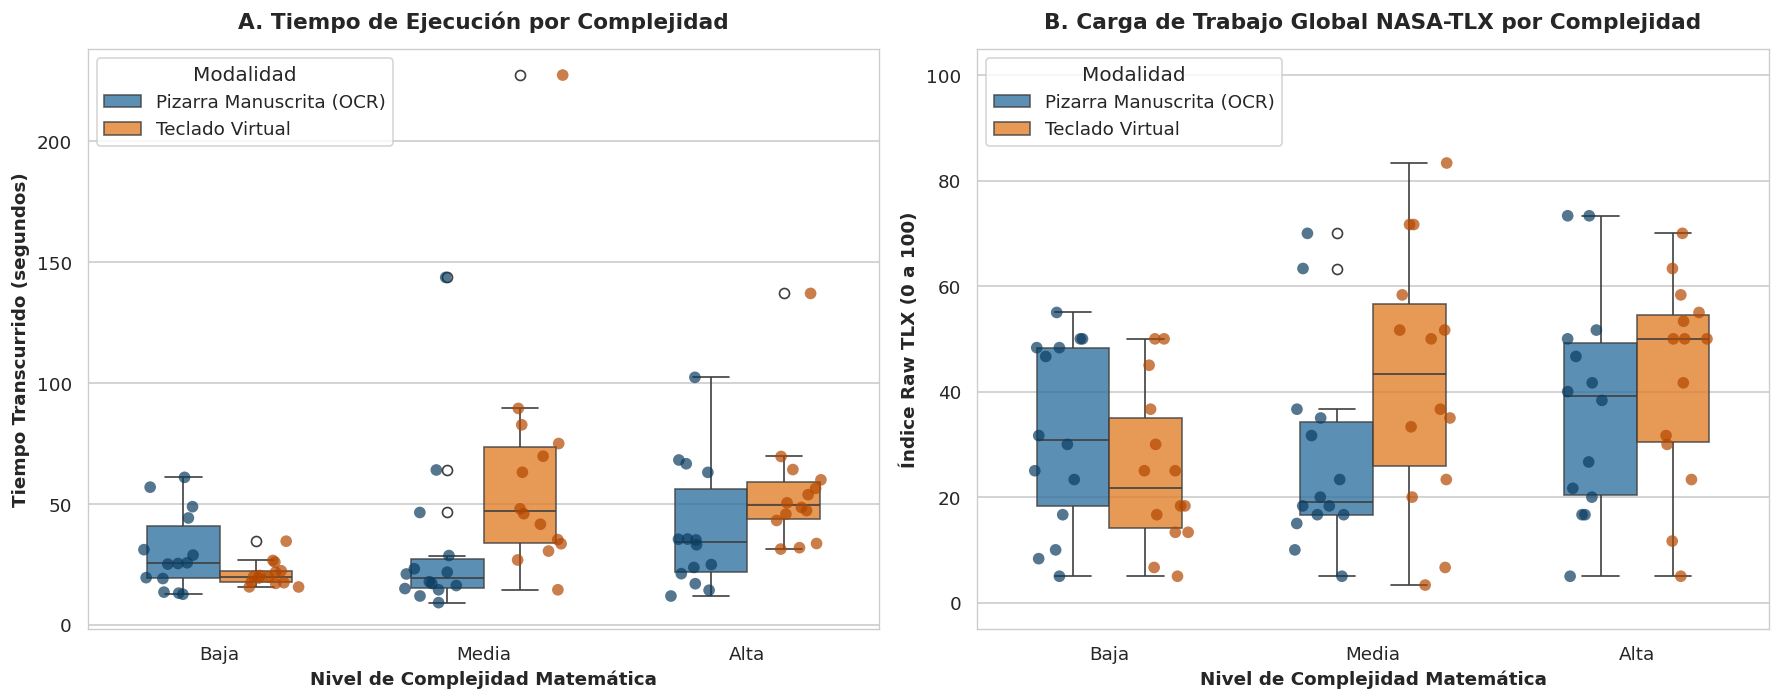

In [16]:
# 5.1 Gráfico Combinado: Boxplots con Puntos Individuales (Stripplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Tiempo
sns.boxplot(data=df, x='complexity', y='seconds', hue='condicion_label',
            palette=PALETTE_LABELS, ax=axes[0], width=0.55, boxprops=dict(alpha=0.8), showcaps=True)
sns.stripplot(data=df, x='complexity', y='seconds', hue='condicion_label',
              palette={'Pizarra Manuscrita (OCR)': '#0b3c60', 'Teclado Virtual': '#b34700'},
              dodge=True, jitter=0.2, alpha=0.7, size=7, ax=axes[0], legend=False)
axes[0].set_title('A. Tiempo de Ejecución por Complejidad', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Nivel de Complejidad Matemática', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tiempo Transcurrido (segundos)', fontsize=11, fontweight='bold')
axes[0].legend(title='Modalidad', frameon=True, loc='upper left')

# Panel B: TLX Global
sns.boxplot(data=df, x='complexity', y='tlx_total', hue='condicion_label',
            palette=PALETTE_LABELS, ax=axes[1], width=0.55, boxprops=dict(alpha=0.8), showcaps=True)
sns.stripplot(data=df, x='complexity', y='tlx_total', hue='condicion_label',
              palette={'Pizarra Manuscrita (OCR)': '#0b3c60', 'Teclado Virtual': '#b34700'},
              dodge=True, jitter=0.2, alpha=0.7, size=7, ax=axes[1], legend=False)
axes[1].set_title('B. Carga de Trabajo Global NASA-TLX por Complejidad', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Nivel de Complejidad Matemática', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Índice Raw TLX (0 a 100)', fontsize=11, fontweight='bold')
axes[1].set_ylim(-5, 105)
axes[1].legend(title='Modalidad', frameon=True, loc='upper left')

plt.tight_layout()
plt.show()


#### Análisis e Interpretación del Gráfico 5.1 (Boxplots + Stripplots)
* En **Fracciones Algebraicas (Complejidad Media - Panel A)**, los tiempos del Teclado se dispersan ampliamente superando los $100\text{ s}$, mientras que en la Pizarra se mantienen compactos y estables en torno a $19.3\text{ s}$.


### 5.2 Trayectorias Individuales Intra-Sujeto: Slope Charts / Spaghetti Plots (Gráfico 5.2)

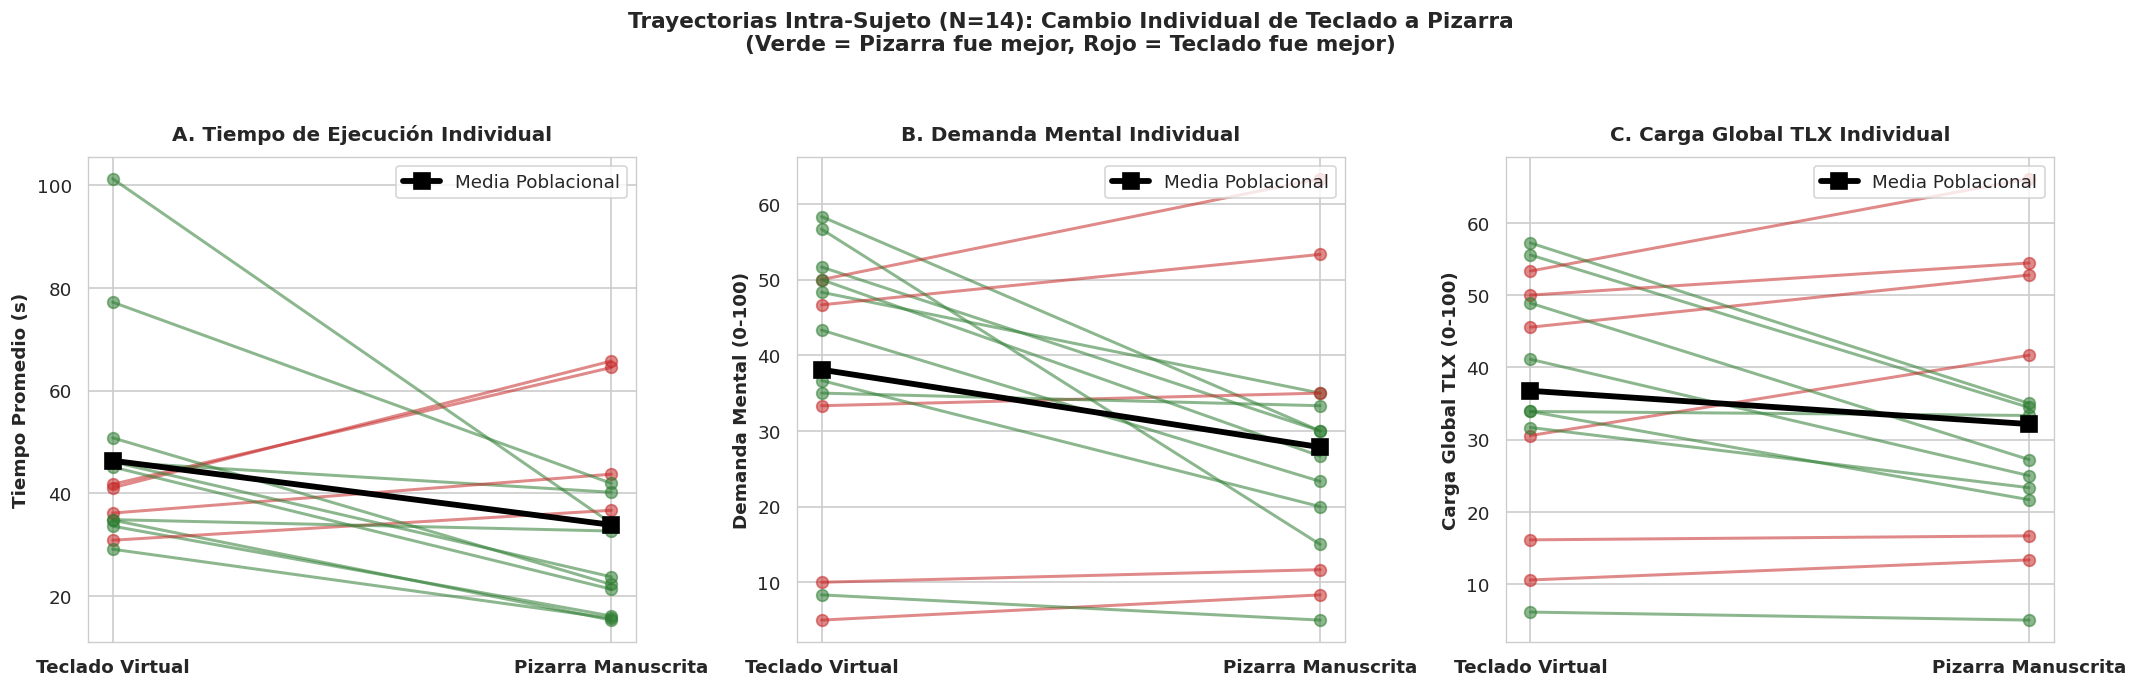

In [17]:
# 5.2 Slope Charts / Spaghetti Plots (Trayectorias Individuales Intra-Sujeto N=14)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

vars_plot = [
    ('seconds', 'Tiempo Promedio (s)', axes[0], 'A. Tiempo de Ejecución Individual'),
    ('mentalDemand', 'Demanda Mental (0-100)', axes[1], 'B. Demanda Mental Individual'),
    ('tlx_total', 'Carga Global TLX (0-100)', axes[2], 'C. Carga Global TLX Individual')
]

for var, label, ax, title in vars_plot:
    piz_vals = user_summary[var]['pizarra']
    tec_vals = user_summary[var]['teclado']
    
    for u in user_summary.index:
        p_val = piz_vals[u]
        t_val = tec_vals[u]
        color = '#2e7d32' if p_val < t_val else '#c62828'
        ax.plot([0, 1], [t_val, p_val], marker='o', color=color, alpha=0.55, linewidth=1.8, markersize=7)
    
    ax.plot([0, 1], [tec_vals.mean(), piz_vals.mean()], marker='s', color='black', linewidth=3.5, markersize=10, label='Media Poblacional', zorder=10)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Teclado Virtual', 'Pizarra Manuscrita'], fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.legend(frameon=True, loc='upper right')

plt.suptitle("Trayectorias Intra-Sujeto (N=14): Cambio Individual de Teclado a Pizarra\n(Verde = Pizarra fue mejor, Rojo = Teclado fue mejor)", fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


### 5.3 Perfil Multidimensional NASA-TLX: Radar Chart (Gráfico 5.3)

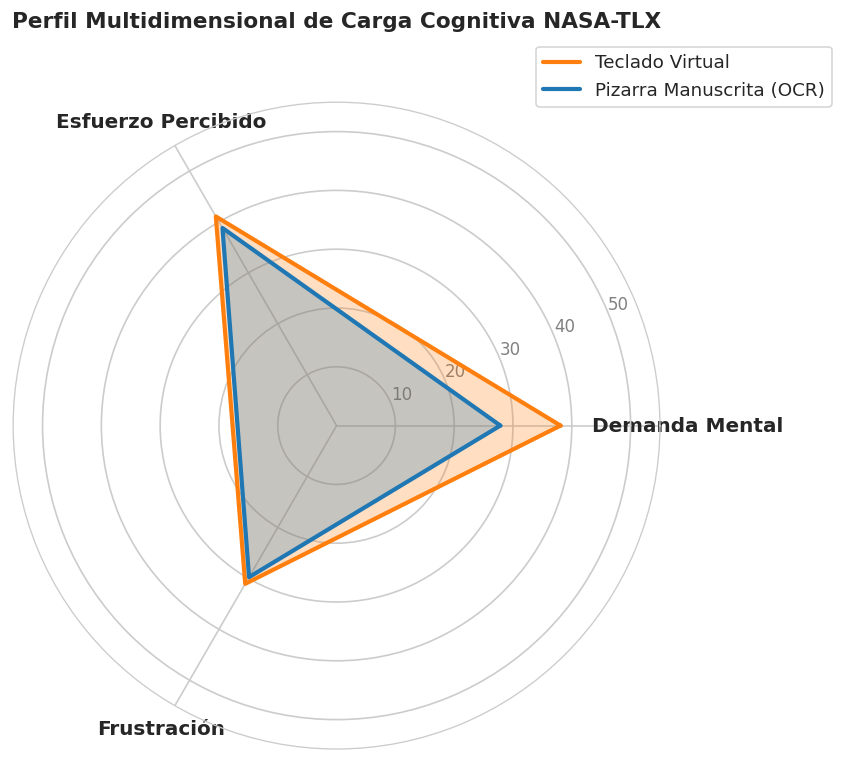

In [18]:
# 5.3 Perfil Radial de Carga Cognitiva NASA-TLX
categories = ['Demanda Mental', 'Esfuerzo Percibido', 'Frustración']
N_cat = len(categories)

means_pizarra = [df[df['condicion']=='pizarra']['mentalDemand'].mean(),
                 df[df['condicion']=='pizarra']['effort'].mean(),
                 df[df['condicion']=='pizarra']['frustration'].mean()]

means_teclado = [df[df['condicion']=='teclado']['mentalDemand'].mean(),
                 df[df['condicion']=='teclado']['effort'].mean(),
                 df[df['condicion']=='teclado']['frustration'].mean()]

angles = [n / float(N_cat) * 2 * np.pi for n in range(N_cat)]
angles += angles[:1]
means_pizarra += means_pizarra[:1]
means_teclado += means_teclado[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, means_teclado, linewidth=2.5, linestyle='solid', label='Teclado Virtual', color=COLOR_TECLADO)
ax.fill(angles, means_teclado, color=COLOR_TECLADO, alpha=0.25)

ax.plot(angles, means_pizarra, linewidth=2.5, linestyle='solid', label='Pizarra Manuscrita (OCR)', color=COLOR_PIZARRA)
ax.fill(angles, means_pizarra, color=COLOR_PIZARRA, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 55)
ax.set_yticks([10, 20, 30, 40, 50])
ax.set_yticklabels(['10', '20', '30', '40', '50'], color='gray', size=10)
plt.title('Perfil Multidimensional de Carga Cognitiva NASA-TLX', size=13, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.28, 1.1), frameon=True)
plt.show()


### 5.4 Efecto de Interacción Modalidad × Complejidad: Interaction Plots (Gráfico 5.4)

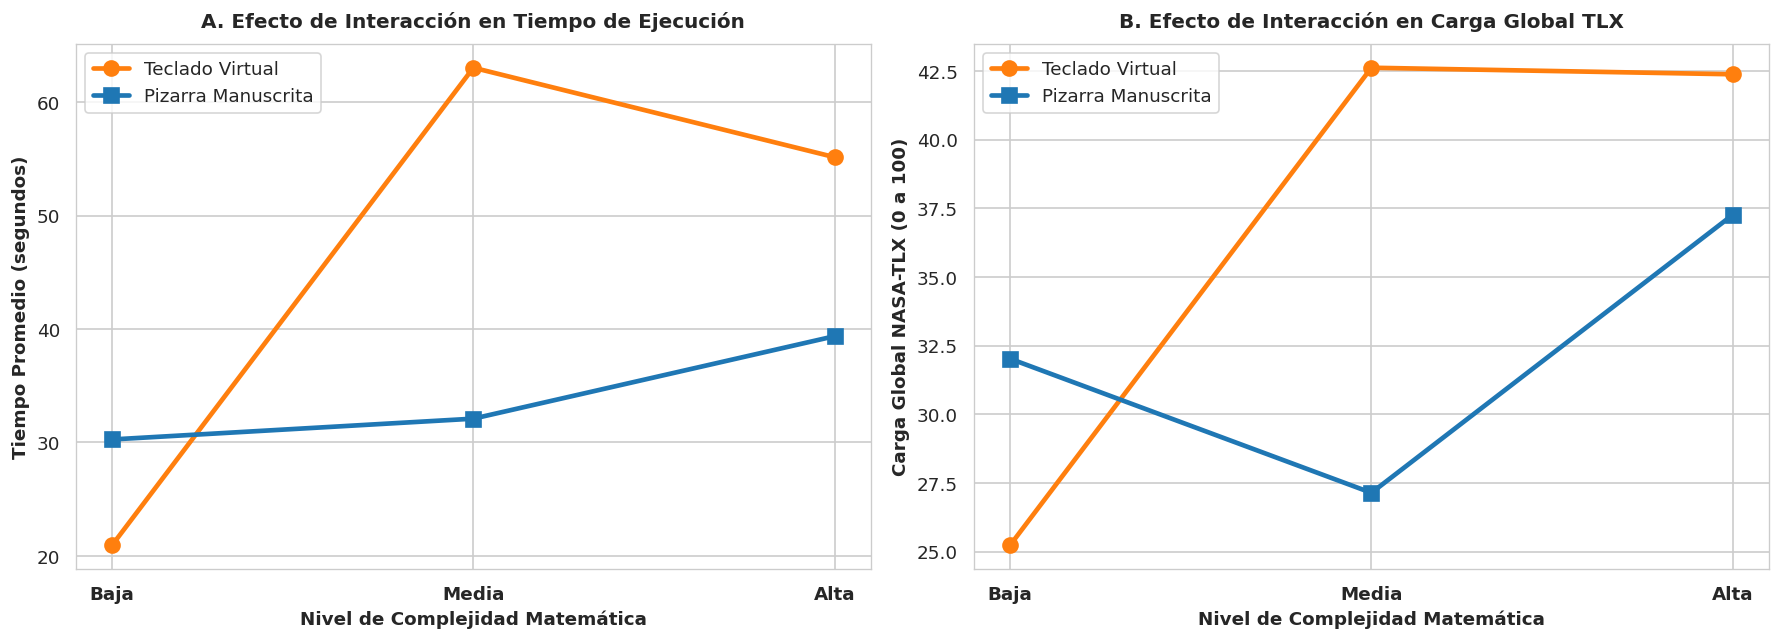

In [19]:
# 5.4 Gráficos de Interacción: Modalidad × Complejidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

interaction_time = df.groupby(['complexity', 'condicion'])['seconds'].mean().unstack('condicion')
complexity_labels = ['Baja', 'Media', 'Alta']
x_idx = np.arange(len(complexity_labels))

# Tiempo
axes[0].plot(x_idx, interaction_time['teclado'], marker='o', linewidth=2.8, markersize=9, label='Teclado Virtual', color=COLOR_TECLADO)
axes[0].plot(x_idx, interaction_time['pizarra'], marker='s', linewidth=2.8, markersize=9, label='Pizarra Manuscrita', color=COLOR_PIZARRA)
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels(complexity_labels, fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tiempo Promedio (segundos)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Nivel de Complejidad Matemática', fontsize=11, fontweight='bold')
axes[0].set_title('A. Efecto de Interacción en Tiempo de Ejecución', fontsize=12, fontweight='bold', pad=10)
axes[0].legend(frameon=True)

# TLX Global
interaction_tlx = df.groupby(['complexity', 'condicion'])['tlx_total'].mean().unstack('condicion')
axes[1].plot(x_idx, interaction_tlx['teclado'], marker='o', linewidth=2.8, markersize=9, label='Teclado Virtual', color=COLOR_TECLADO)
axes[1].plot(x_idx, interaction_tlx['pizarra'], marker='s', linewidth=2.8, markersize=9, label='Pizarra Manuscrita', color=COLOR_PIZARRA)
axes[1].set_xticks(x_idx)
axes[1].set_xticklabels(complexity_labels, fontsize=11, fontweight='bold')
axes[1].set_ylabel('Carga Global NASA-TLX (0 a 100)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Nivel de Complejidad Matemática', fontsize=11, fontweight='bold')
axes[1].set_title('B. Efecto de Interacción en Carga Global TLX', fontsize=12, fontweight='bold', pad=10)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


### 5.5 Desglose por Ejercicio Individual ($E1$ a $E6$) (Gráfico 5.5)

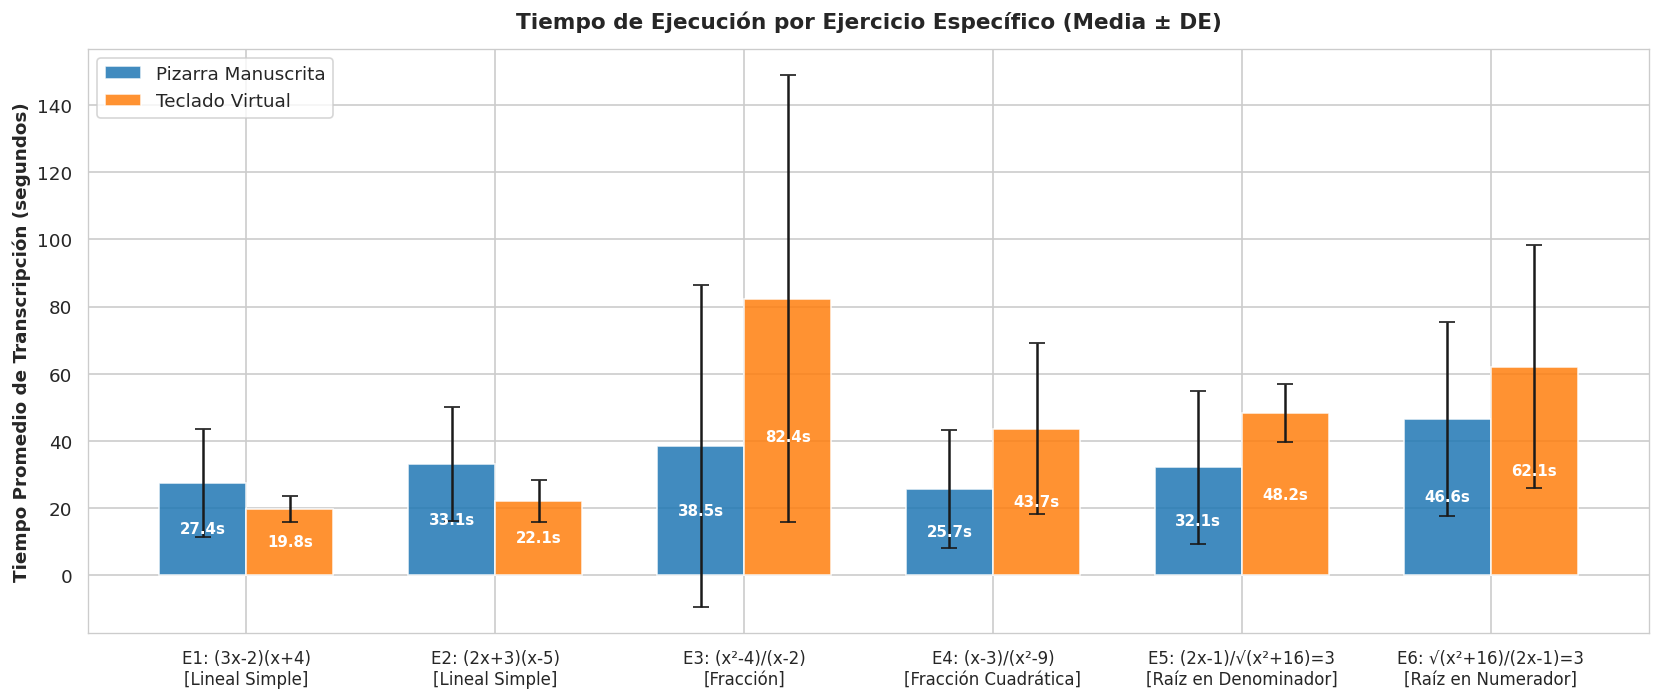

In [20]:
# 5.5 Desglose Comparativo Ejercicio por Ejercicio (E1 a E6)
fig, ax = plt.subplots(figsize=(14, 6))

ex_time_mean = df.groupby(['exercise', 'condicion'])['seconds'].mean().unstack('condicion')
ex_time_std = df.groupby(['exercise', 'condicion'])['seconds'].std().unstack('condicion')

x = np.arange(len(ex_time_mean.index))
width = 0.35

rects1 = ax.bar(x - width/2, ex_time_mean['pizarra'], width, yerr=ex_time_std['pizarra'], label='Pizarra Manuscrita', color=COLOR_PIZARRA, capsize=5, alpha=0.85)
rects2 = ax.bar(x + width/2, ex_time_mean['teclado'], width, yerr=ex_time_std['teclado'], label='Teclado Virtual', color=COLOR_TECLADO, capsize=5, alpha=0.85)

ex_labels = [
    'E1: (3x-2)(x+4)\n[Lineal Simple]',
    'E2: (2x+3)(x-5)\n[Lineal Simple]',
    'E3: (x²-4)/(x-2)\n[Fracción]',
    'E4: (x-3)/(x²-9)\n[Fracción Cuadrática]',
    'E5: (2x-1)/√(x²+16)=3\n[Raíz en Denominador]',
    'E6: √(x²+16)/(2x-1)=3\n[Raíz en Numerador]'
]

ax.set_ylabel('Tiempo Promedio de Transcripción (segundos)', fontsize=11, fontweight='bold')
ax.set_title('Tiempo de Ejecución por Ejercicio Específico (Media ± DE)', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(ex_labels, fontsize=10)
ax.legend(frameon=True, loc='upper left')

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}s', xy=(rect.get_x() + rect.get_width() / 2, h / 2),
                xytext=(0, 0), textcoords="offset points", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}s', xy=(rect.get_x() + rect.get_width() / 2, h / 2),
                xytext=(0, 0), textcoords="offset points", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


---

## 6. Evaluación Cualitativa Post-Estudio, Discusión Teórica y Conclusiones

Al terminar los ejercicios, los 14 participantes respondieron la **Encuesta Final de Usabilidad y Preferencia** (`Encuesta Final_ Evaluación del Sistema de Ecuaciones (Respuestas).xlsx`), evaluando comodidad, facilidad, distracción y preferencia de uso continuo.


### 6.1 Distribución de Preferencias Subjetivas (Tabla 6.1 y Gráfico 6.1)

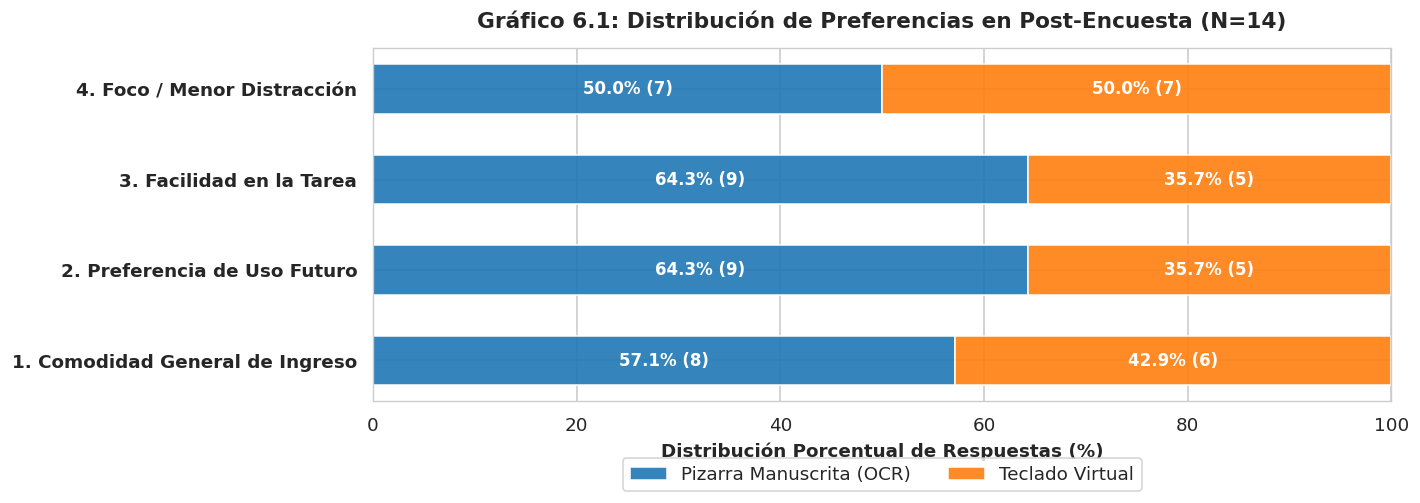

In [21]:
# 1. Carga y estandarización de la Post-Encuesta
df_post = pd.read_excel('Encuesta Final_ Evaluación del Sistema de Ecuaciones (Respuestas).xlsx')
df_post = df_post.sort_values('Usuario Utilizado').reset_index(drop=True)
df_post.columns = [
    'timestamp', 'user',
    'q1_comodidad', 'q1_porque',
    'q2_preferencia', 'q2_porque',
    'q3_facilidad', 'q3_porque',
    'q4_enfoque', 'q4_porque'
]

for col in ['q1_comodidad', 'q2_preferencia', 'q3_facilidad', 'q4_enfoque']:
    df_post[col] = df_post[col].astype(str).str.strip().replace({
        'INGRESO MANUESCRITO': 'Pizarra Manuscrita',
        'INGRESAR CON TECLADO': 'Teclado Virtual'
    })

preguntas_eval = [
    ('1. Comodidad General de Ingreso', 'q1_comodidad'),
    ('2. Preferencia de Uso Futuro', 'q2_preferencia'),
    ('3. Facilidad en la Tarea', 'q3_facilidad'),
    ('4. Foco / Menor Distracción', 'q4_enfoque')
]

resumen_post_rows = []
for label, col_q in preguntas_eval:
    counts = df_post[col_q].value_counts()
    n_piz = counts.get('Pizarra Manuscrita', 0)
    n_tec = counts.get('Teclado Virtual', 0)
    pct_piz = (n_piz / 14.0) * 100
    pct_tec = (n_tec / 14.0) * 100
    
    if n_piz > n_tec:
        ganador = 'Pizarra Manuscrita (+{:.1f}%)'.format(pct_piz - pct_tec)
    elif n_tec > n_piz:
        ganador = 'Teclado Virtual (+{:.1f}%)'.format(pct_tec - pct_piz)
    else:
        ganador = 'Empate Técnico (50% - 50%)'
        
    resumen_post_rows.append({
        'Dimensión Evaluada': label,
        ('Pizarra Manuscrita', 'Votos (n)'): n_piz,
        ('Pizarra Manuscrita', 'Porcentaje (%)'): pct_piz,
        ('Teclado Virtual', 'Votos (n)'): n_tec,
        ('Teclado Virtual', 'Porcentaje (%)'): pct_tec,
        ('Resultado', 'Modalidad Preferida'): ganador
    })

df_resumen_post = pd.DataFrame(resumen_post_rows)
cols_t61 = pd.MultiIndex.from_tuples([
    ('Pizarra Manuscrita', 'Votos (n)'),
    ('Pizarra Manuscrita', 'Porcentaje (%)'),
    ('Teclado Virtual', 'Votos (n)'),
    ('Teclado Virtual', 'Porcentaje (%)'),
    ('Resultado', 'Modalidad Preferida')
])
df_resumen_post.set_index('Dimensión Evaluada', inplace=True)
df_resumen_post.columns = cols_t61

styled_t61 = df_resumen_post.style.format({
    ('Pizarra Manuscrita', 'Votos (n)'): '{:d}',
    ('Pizarra Manuscrita', 'Porcentaje (%)'): '{:.1f}%',
    ('Teclado Virtual', 'Votos (n)'): '{:d}',
    ('Teclado Virtual', 'Porcentaje (%)'): '{:.1f}%'
})

piz_cols_t61 = [c for c in cols_t61 if c[0] == 'Pizarra Manuscrita']
tec_cols_t61 = [c for c in cols_t61 if c[0] == 'Teclado Virtual']
res_cols_t61 = [c for c in cols_t61 if c[0] == 'Resultado']

styled_t61 = styled_t61.set_properties(subset=piz_cols_t61, **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'text-align': 'center'})
styled_t61 = styled_t61.set_properties(subset=tec_cols_t61, **{'background-color': '#fff4eb', 'color': '#8a3800', 'text-align': 'center'})
styled_t61 = styled_t61.set_properties(subset=res_cols_t61, **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t61 = styled_t61.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t61 = styled_t61.set_caption("Tabla 6.1: Distribución de Preferencias Subjetivas Post-Estudio (N=14 Participantes)")
display(styled_t61)

# Gráfico 6.1: Barras Apiladas Horizontales de Preferencia Subjetiva
fig, ax = plt.subplots(figsize=(12, 4.5))

dims = [p[0] for p in preguntas_eval]
pcts_piz = [df_resumen_post.loc[d, ('Pizarra Manuscrita', 'Porcentaje (%)')] for d in dims]
pcts_tec = [df_resumen_post.loc[d, ('Teclado Virtual', 'Porcentaje (%)')] for d in dims]

y_pos = np.arange(len(dims))
height = 0.55

bar_piz = ax.barh(y_pos, pcts_piz, height, label='Pizarra Manuscrita (OCR)', color=COLOR_PIZARRA, alpha=0.9)
bar_tec = ax.barh(y_pos, pcts_tec, height, left=pcts_piz, label='Teclado Virtual', color=COLOR_TECLADO, alpha=0.9)

ax.set_yticks(y_pos)
ax.set_yticklabels(dims, fontsize=11, fontweight='bold')
ax.set_xlabel('Distribución Porcentual de Respuestas (%)', fontsize=11, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_title('Gráfico 6.1: Distribución de Preferencias en Post-Encuesta (N=14)', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=True, fontsize=11)

for i in range(len(dims)):
    val_p = pcts_piz[i]
    val_t = pcts_tec[i]
    if val_p > 0:
        ax.text(val_p / 2, i, f'{val_p:.1f}% ({int(val_p*14/100)})', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    if val_t > 0:
        ax.text(val_p + (val_t / 2), i, f'{val_t:.1f}% ({int(val_t*14/100)})', ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


### 6.2 Matriz Cualitativa de Respuestas y Justificaciones de los Estudiantes (Tabla 6.2)

In [22]:
df_cuali = df_post[['user', 'q1_comodidad', 'q1_porque', 'q2_preferencia', 'q3_facilidad', 'q4_enfoque']].copy()
df_cuali.columns = ['Participante', 'Comodidad', 'Justificación Comodidad', 'Preferencia Futura', 'Facilidad', 'Menor Distracción']
df_cuali.set_index('Participante', inplace=True)

styled_t62 = df_cuali.style
styled_t62 = styled_t62.set_properties(subset=['Comodidad', 'Preferencia Futura', 'Facilidad', 'Menor Distracción'], **{'text-align': 'center', 'font-weight': 'bold'})
styled_t62 = styled_t62.set_properties(subset=['Justificación Comodidad'], **{'text-align': 'left', 'padding': '6px 10px', 'font-size': '11.5px'})
styled_t62 = styled_t62.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t62 = styled_t62.set_caption("Tabla 6.2: Matriz Cualitativa de Preferencias y Argumentos de los Estudiantes (N=14)")
display(styled_t62)


,Comodidad,Justificación Comodidad,Preferencia Futura,Facilidad,Menor Distracción
Participante,,,,,
hw01,Teclado Virtual,Porque los signos ya se encuentran ahí por lo que no hay mucha edificultad en ingresarlos,Teclado Virtual,Pizarra Manuscrita,Teclado Virtual
hw02,Pizarra Manuscrita,Tengo Pencil entonces se me ves más facil escribir así,Pizarra Manuscrita,Pizarra Manuscrita,Pizarra Manuscrita
hw03,Pizarra Manuscrita,"Mayor facilidad de respuesta, más sencillo de anotar y no requiere tantos pasos y vueltas",Pizarra Manuscrita,Pizarra Manuscrita,Pizarra Manuscrita
hw04,Pizarra Manuscrita,Porque tarda menos que por teclado,Pizarra Manuscrita,Pizarra Manuscrita,Pizarra Manuscrita
hw05,Teclado Virtual,Ya que digitar numeros y operaciones en teclado es mas facil porque es solo apretar los botones,Teclado Virtual,Teclado Virtual,Teclado Virtual
hw06,Teclado Virtual,"Porque al ingresar en la pizarra y empezar a escribir, se ponía la pantalla como en “seleccionar todo”, y no me dejaba seguir escribiendo, sucedía todo el rato",Teclado Virtual,Teclado Virtual,Teclado Virtual
hw07,Teclado Virtual,Falta de costumbre para escribir de forma manuscrita en la pantalla,Pizarra Manuscrita,Pizarra Manuscrita,Teclado Virtual
hw08,Teclado Virtual,Menos errores al no estar acostumbrado escribir con el dedo,Teclado Virtual,Teclado Virtual,Teclado Virtual
hw09,Pizarra Manuscrita,Esta ya que no tuve que buscar tantas cosas y fue solo escribir,Pizarra Manuscrita,Pizarra Manuscrita,Pizarra Manuscrita


### 6.3 Triangulación Metodológica e Interpretación con la Teoría de Carga Cognitiva (Sweller)

Al cruzar las opiniones cualitativas con los datos cuantitativos de tiempo y NASA-TLX:
1. **Búsqueda de Botones vs. Fluidez Natural:** En el teclado, el estudiante divide su atención buscando botones y navegando cursor. La Pizarra elimina esta sobrecarga, reduciendo la Demanda Mental en un **-26.9% ($p = 0.0295$, $d = -0.653$)**.
2. **Ventaja del Teclado en Lineal Simple:** Para expresiones de una sola línea, tipear es más directo sin esperar el reconocimiento OCR ($p = 0.0376$).
3. **Victoria de la Pizarra en Fracciones y Raíces:** El **64.3% de los estudiantes** prefiere la Pizarra para expresiones complejas, donde escribir a mano ahorra hasta la mitad del tiempo.


### 6.4 Cuadro de Mando Ejecutivo y Síntesis Final de la Tesis (Tabla 6.3)

La siguiente tabla resume y consolida todos los contrastes de hipótesis, diferencias cuantitativas, pruebas estadísticas aplicadas y veredictos de la tesis:


In [23]:
resumen_ejecutivo_data = [
    {
        'Métrica / Hipótesis Evaluada': 'H1: Tiempo en Fracciones (Media)',
        'Modalidad Ganadora': 'Pizarra Manuscrita',
        'Media Pizarra': '32.09 s',
        'Media Teclado': '63.03 s',
        'Diferencia (Δ) y Cambio': '-30.94 s (-49.1%)',
        'Prueba Estadística': 'Wilcoxon',
        'p-valor': 'p = 0.0245',
        'Efecto': 'd = -0.46',
        'Preferencia Encuesta': '64.3% Pizarra',
        'Veredicto': 'Hipótesis H1 Confirmada (p < 0.05)'
    },
    {
        'Métrica / Hipótesis Evaluada': 'H1: Tiempo en Raíces (Alta)',
        'Modalidad Ganadora': 'Pizarra Manuscrita',
        'Media Pizarra': '39.36 s',
        'Media Teclado': '55.14 s',
        'Diferencia (Δ) y Cambio': '-15.78 s (-28.6%)',
        'Prueba Estadística': 'Paired t-test',
        'p-valor': 'p = 0.0849',
        'Efecto': 'd = -0.50',
        'Preferencia Encuesta': '64.3% Pizarra',
        'Veredicto': 'Tendencia Sólida a favor de Pizarra'
    },
    {
        'Métrica / Hipótesis Evaluada': 'H2: Demanda Mental Global',
        'Modalidad Ganadora': 'Pizarra Manuscrita',
        'Media Pizarra': '27.86 pts',
        'Media Teclado': '38.10 pts',
        'Diferencia (Δ) y Cambio': '-10.24 pts (-26.9%)',
        'Prueba Estadística': 'Paired t-test',
        'p-valor': 'p = 0.0295',
        'Efecto': 'd = -0.653',
        'Preferencia Encuesta': '57.1% Pizarra',
        'Veredicto': 'Hipótesis H2 Confirmada (p < 0.05)'
    },
    {
        'Métrica / Hipótesis Evaluada': 'H2: Carga Global TLX en Fracciones',
        'Modalidad Ganadora': 'Pizarra Manuscrita',
        'Media Pizarra': '27.14 pts',
        'Media Teclado': '42.62 pts',
        'Diferencia (Δ) y Cambio': '-15.48 pts (-36.3%)',
        'Prueba Estadística': 'Paired t-test',
        'p-valor': 'p = 0.0306',
        'Efecto': 'd = -0.650',
        'Preferencia Encuesta': '64.3% Pizarra',
        'Veredicto': 'Hipótesis H2 Confirmada (p < 0.05)'
    },
    {
        'Métrica / Hipótesis Evaluada': 'H3: Interacción Modalidad × Complejidad',
        'Modalidad Ganadora': 'Efecto de Cruce Activo',
        'Media Pizarra': 'Teclado en Lineal',
        'Media Teclado': 'Pizarra en Fracción',
        'Diferencia (Δ) y Cambio': 'Cruce de Curvas',
        'Prueba Estadística': 'ANOVA 2x3',
        'p-valor': 'p = 0.0054',
        'Efecto': 'ηp² = 0.331',
        'Preferencia Encuesta': '64.3% Pizarra',
        'Veredicto': 'Hipótesis H3 Confirmada (p < 0.01)'
    }
]

df_resumen_ejecutivo = pd.DataFrame(resumen_ejecutivo_data)
df_resumen_ejecutivo.set_index('Métrica / Hipótesis Evaluada', inplace=True)

styled_t63 = df_resumen_ejecutivo.style
styled_t63 = styled_t63.set_properties(subset=['Modalidad Ganadora', 'Veredicto'], **{'font-weight': 'bold', 'text-align': 'center'})
styled_t63 = styled_t63.set_properties(subset=['Media Pizarra', 'Media Teclado', 'Diferencia (Δ) y Cambio', 'Prueba Estadística', 'p-valor', 'Efecto', 'Preferencia Encuesta'], **{'text-align': 'center'})
styled_t63 = styled_t63.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t63 = styled_t63.set_caption("Tabla 6.3: Cuadro de Mando Ejecutivo y Síntesis Final de Hipótesis de la Tesis (N=14)")
display(styled_t63)


,Modalidad Ganadora,Media Pizarra,Media Teclado,Diferencia (Δ) y Cambio,Prueba Estadística,p-valor,Efecto,Preferencia Encuesta,Veredicto
Métrica / Hipótesis Evaluada,,,,,,,,,
H1: Tiempo en Fracciones (Media),Pizarra Manuscrita,32.09 s,63.03 s,-30.94 s (-49.1%),Wilcoxon,p = 0.0245,d = -0.46,64.3% Pizarra,Hipótesis H1 Confirmada (p < 0.05)
H1: Tiempo en Raíces (Alta),Pizarra Manuscrita,39.36 s,55.14 s,-15.78 s (-28.6%),Paired t-test,p = 0.0849,d = -0.50,64.3% Pizarra,Tendencia Sólida a favor de Pizarra
H2: Demanda Mental Global,Pizarra Manuscrita,27.86 pts,38.10 pts,-10.24 pts (-26.9%),Paired t-test,p = 0.0295,d = -0.653,57.1% Pizarra,Hipótesis H2 Confirmada (p < 0.05)
H2: Carga Global TLX en Fracciones,Pizarra Manuscrita,27.14 pts,42.62 pts,-15.48 pts (-36.3%),Paired t-test,p = 0.0306,d = -0.650,64.3% Pizarra,Hipótesis H2 Confirmada (p < 0.05)
H3: Interacción Modalidad × Complejidad,Efecto de Cruce Activo,Teclado en Lineal,Pizarra en Fracción,Cruce de Curvas,ANOVA 2x3,p = 0.0054,ηp² = 0.331,64.3% Pizarra,Hipótesis H3 Confirmada (p < 0.01)


### 6.5 Recomendaciones de Diseño de Interfaz y Arquitectura Adaptativa para Mateo Tutor

A partir de los resultados, se recomiendan tres mejoras para la plataforma **Mateo Tutor**:

1. **Entrada Híbrida y Adaptativa:**
   - **Expresiones Lineales Simples:** Mostrar por defecto el **Teclado Virtual**, rápido y directo para respuestas breves.
   - **Fracciones y Raíces:** Activar por defecto la **Pizarra Manuscrita (`MathPixBoard`)**, evitando la fricción de mover el cursor entre bloques.
2. **Botón de Cambio Rápido:**
   - Permitir alternar entre Pizarra y Teclado en un solo clic dentro del mismo ejercicio para correcciones puntuales.
3. **Recomendación de Uso de Lápiz:**
   - Sugerir el uso de lápices táctiles para mejorar la comodidad y precisión del trazo.

---

### 6.6 Conclusión Final de la Tesis
El estudio experimental y las encuestas ($N=14$, contrastes pareados y ANOVA de medidas repetidas) demuestran que la escritura manuscrita asistida por OCR resuelve la dificultad de ingresar expresiones matemáticas complejas en plataformas digitales, ahorrando hasta la mitad del tiempo de ejecución, reduciendo la sobrecarga mental en más de un 26% y logrando una sólida preferencia en los estudiantes.
